### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression



pd.set_option('display.max_columns', None)

### Load Data

In [2]:
path = '../../data/groceries/feature_frame.csv'
df_raw = pd.read_csv(path)

In [3]:
df_raw.head(5)

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,discount_pct,vendor,global_popularity,count_adults,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.000000,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.038462,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,0.0,0.0,0.081052,0.053512,clearspring,0.038462,2.0,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

### Data Preprocessing

- Requirement: Filter the dataset for orders with at least 5 items.

In [5]:
def convert_to_datetime(df, columns =['created_at', 'order_date'])->pd.DataFrame:
    for col in columns:
        df[col] = pd.to_datetime(df[col])
    return df
                        

In [6]:
def filtered_dataframe(df, min_prod: int = 5)->pd.DataFrame:
    df_filtered = df[df.groupby('order_id')['outcome'].transform('sum')>= min_prod]
    return df_filtered


In [7]:
df = (df_raw
            .pipe(convert_to_datetime)
            .pipe(filtered_dataframe)
)

### Sample Dataset

The original dataset contains 2,600 orders, each with one row per product and an outcome column indicating whether the item was purchased. 

For computational efficiency, the analysis is conducted on a sample of 500 orders.

In [10]:
orders = df.order_id.unique()

sample_orders = np.random.choice(orders, size= 500, replace=False)

df = df[df['order_id'].isin(sample_orders)]

df.shape

(417908, 27)

### Daily Orders Evolution

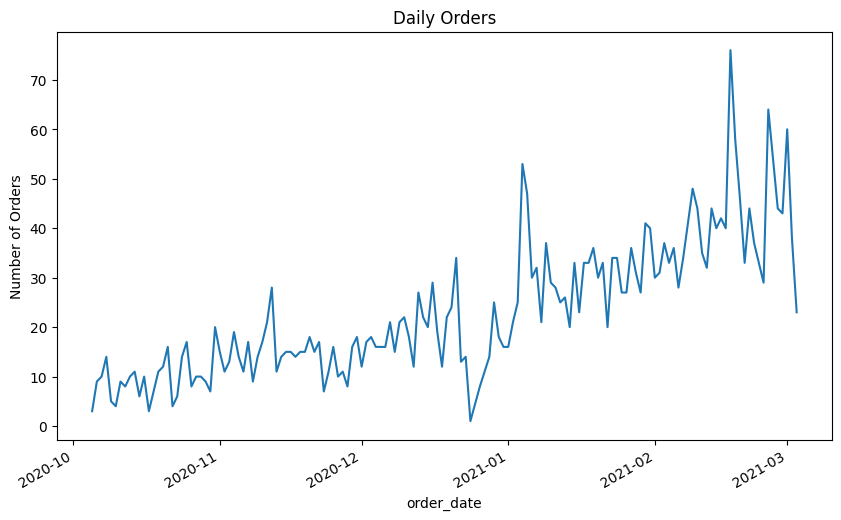

In [10]:
fig, ax = plt.subplots(figsize= (10,6))
df_raw.groupby('order_date')['order_id'].nunique().plot()
plt.title('Daily Orders')
plt.ylabel('Number of Orders')
plt.show()

### Time based split: Train, Validation, Split

In [17]:
daily_orders = df.groupby('order_date')['order_id'].nunique().cumsum()

total_orders = df.order_id.nunique()

train_cutoff = daily_orders[daily_orders <= 0.7 * total_orders].index[-1]
val_cutoff = daily_orders[daily_orders <= 0.9 * total_orders].index[-1]

train = df[df['order_date'] <= train_cutoff]
val = df[(df['order_date'] > train_cutoff) & (df['order_date']<= val_cutoff)]
test = df[df['order_date'] > val_cutoff]

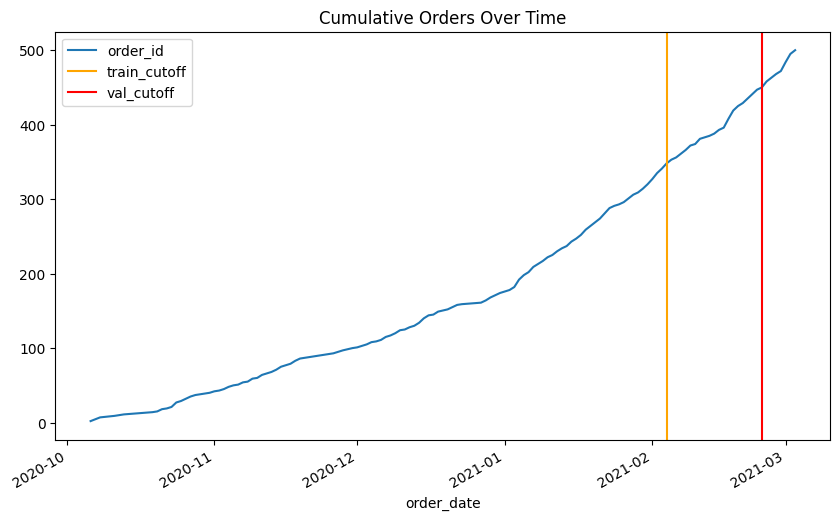

In [18]:
fig, ax = plt.subplots(figsize = (10,6))
daily_orders.plot()
ax.axvline(train_cutoff, color = 'orange', label = 'train_cutoff')
ax.axvline(val_cutoff, color = 'red', label = 'val_cutoff')
ax.legend()
plt.title('Cumulative Orders Over Time')
plt.show()

### Baseline

As a baseline model, global product popularity is used as the predicting variable, assuming that products purchased more frequently across all orders are more likely to be bought by any given customer.

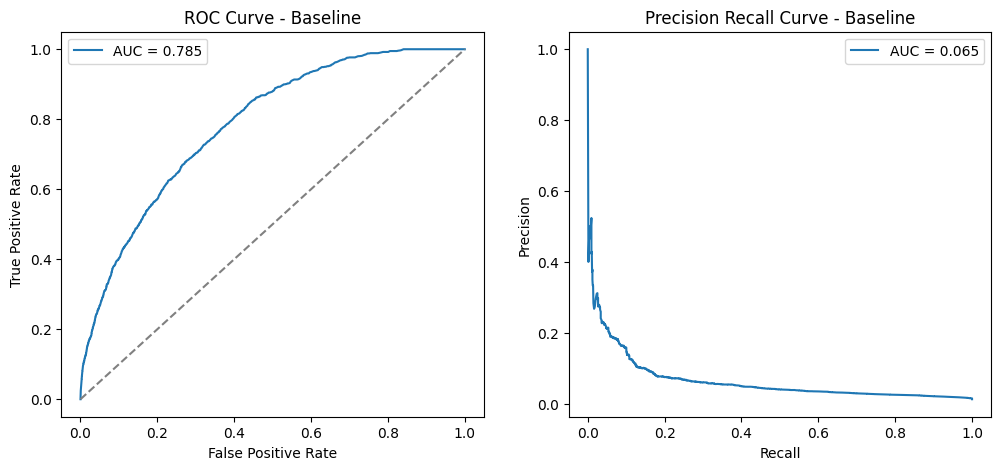

In [19]:
# Baseline Scores 
y_score = val['global_popularity']

# ROC Curve
fpr, tpr, _ = roc_curve(val['outcome'], y_score)
roc_auc = auc(fpr, tpr)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(val['outcome'], y_score)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(1,2,figsize = (12,5))

ax[0].plot(fpr, tpr, label = f'AUC = {roc_auc:.3f}')
ax[0].plot([0,1], [0,1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Baseline')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

ax[1].plot(recall, precision, label = f'AUC = {pr_auc:.3f}')
ax[1].set_title('Precision Recall Curve - Baseline')
ax[1].set_ylabel('Precision')
ax[1].set_xlabel('Recall')
ax[1].legend()
plt.show()

In [25]:
positive_rate = df['outcome'].mean()
positive_rate

0.014440493801112947

- The dataset contains one row per order-product combination, with outcome=1, if the product was purchased in that order. 

- Only 1.4% of these combinations, result in a purchase, which reflects the nature of the problem: a customer buys only a few products out of the entire catalogue.

- A random classifier would achieve a PR AUC of ~0.014, while our baseline model (global_popularity) reaches 0.065, performing 4-5x better than random.

- Precision Recall AUC will be our main metric going forward, as it is more informative than ROC AUC for highly imbalanced datasets.

### Split Features and Target

In [20]:
target = 'outcome'

X_train = train.drop(columns = target)
y_train = train[target]

X_val = val.drop(columns = target)
y_val = val[target]

X_test = test.drop(columns = target)
y_test = test[target]

### Variable selection 

In [21]:
ids = ['order_id', 'user_id', 'variant_id', 'created_at','order_date']
bin = ['ordered_before','abandoned_before', 'active_snoozed', 'set_as_regular']
num = ['user_order_seq','normalised_price','discount_pct','global_popularity',
       'count_adults', 'count_children', 'count_babies', 'count_pets', 
       'people_ex_baby', 'days_since_purchase_variant_id', 
       'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 
       'days_since_purchase_product_type', 'avg_days_to_buy_product_type',
       'std_days_to_buy_product_type']
cat = ['product_type', 'vendor']
target = ['outcome']

### Preprocessing

Standard scaling was applied to numerical features. 

Categorical variables (product_type and vendor) were excluded from the model, as their inclusion via encoding did not yield 
meaningful improvements in predictive performance while significantly increasing 
training time.

In [22]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), num + bin),
    ]
)

### Linear Models

#### Ridge

In [23]:
ridge_model = Pipeline(
    steps = [
        ("preprocess", preprocessor),
        ('model', LogisticRegression(penalty='l2', solver='liblinear',C=1))
    ]
)
ridge_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['user_order_seq',
                                                   'normalised_price',
                                                   'discount_pct',
                                                   'global_popularity',
                                                   'count_adults',
                                                   'count_children',
                                                   'count_babies', 'count_pets',
                                                   'people_ex_baby',
                                                   'days_since_purchase_variant_id',
                                                   'avg_days_to_buy_variant_id',
                                                   'std_days_to_buy_variant_id',
                                                   'days_since_purchase_product_type',
                                                   'avg_days_to_buy_product_type',
                                                   'std_days_to_buy_product_type',
                                                   'ordered_before',
                                                   'abandoned_before',
                                                   'active_snoozed',
                                                   'set_as_regular'])])),
                ('model', LogisticRegression(C=1, solver='liblinear'))])

In [24]:
Cs= (1e-4, 1e-1, 1, 10 ,100) #1/alpha

In [25]:
ridge_preds = {}

for C in Cs:
   model = Pipeline(
      steps = [
         ('preprocessor', preprocessor),
         ('model', LogisticRegression(penalty='l2', solver = 'liblinear', C=C))
      ]
   )

   model.fit(X_train, y_train)

   probs = model.predict_proba(X_val)[:,1]

   ridge_preds[C]= probs


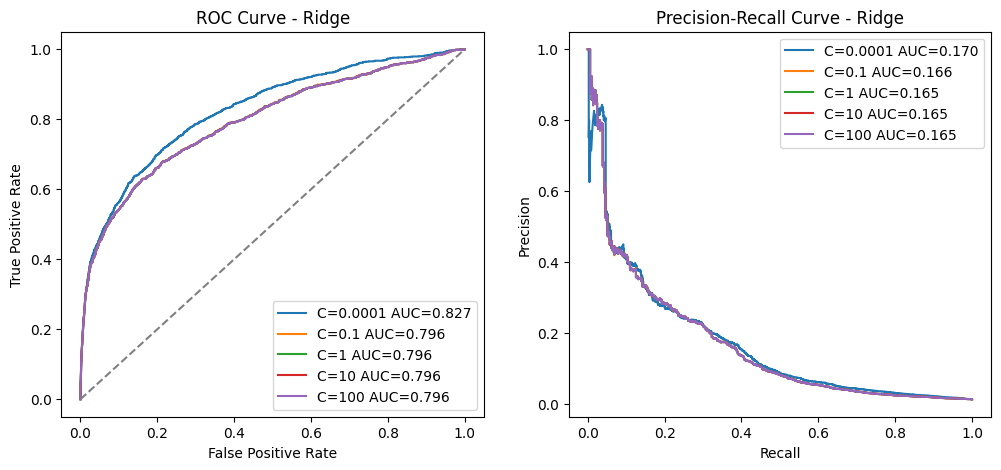

In [27]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

for C in Cs:

    probs = ridge_preds[C]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)

    ax[0].plot(fpr, tpr, label=f'C={C} AUC={roc_auc:.3f}')

    # Precision Recall
    precision, recall, _ = precision_recall_curve(y_val, probs)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'C={C} AUC={pr_auc:.3f}')


# format ROC
ax[0].plot([0,1], [0,1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Ridge')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

# format PR
ax[1].set_title('Precision-Recall Curve - Ridge')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()



#### Lasso

In [28]:
lasso_model = Pipeline(
    steps = [
        ('preprocess', preprocessor),
        ('model', LogisticRegression(penalty='l1', solver= 'liblinear', C=1))
    ]
)

In [29]:
Cs= (1e-4, 1e-1, 1, 10, 100) #1/alpha

In [30]:
lasso_preds = {}

for C in Cs:
    model = Pipeline(
        steps= [
            ('preprocess', preprocessor),
            ('model', LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter = 500))
        ]
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:,1]

    lasso_preds[C] = probs

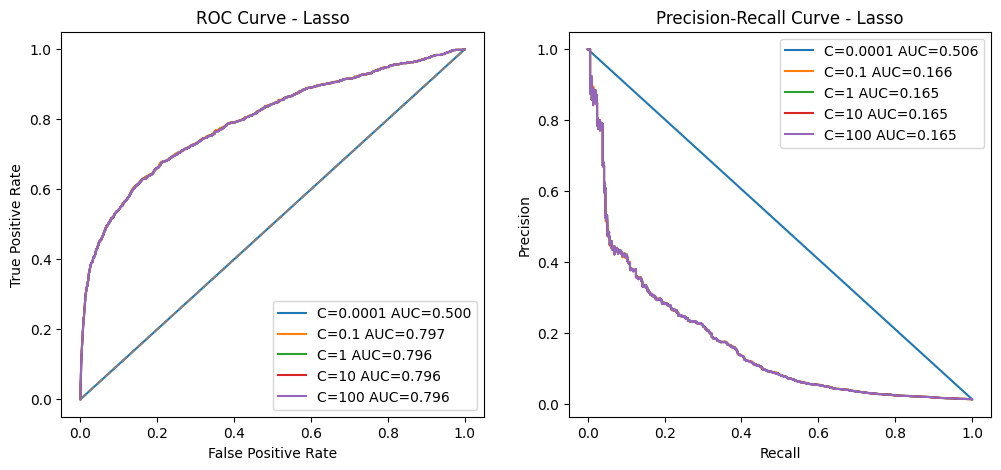

In [31]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

for C in Cs:

    probs = lasso_preds[C]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)

    ax[0].plot(fpr, tpr, label=f'C={C} AUC={roc_auc:.3f}')

    # Precision Recall
    precision, recall, _ = precision_recall_curve(y_val, probs)
    pr_auc = auc(recall, precision)

    ax[1].plot(recall, precision, label=f'C={C} AUC={pr_auc:.3f}')


# formato ROC
ax[0].plot([0,1], [0,1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Lasso')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

# formato PR
ax[1].set_title('Precision-Recall Curve - Lasso')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

la curva azul es porque se aplica tanta regularizacion que lleva muchas variables a 0 y solo puede tomar el valor 0 o 1

### Best Models

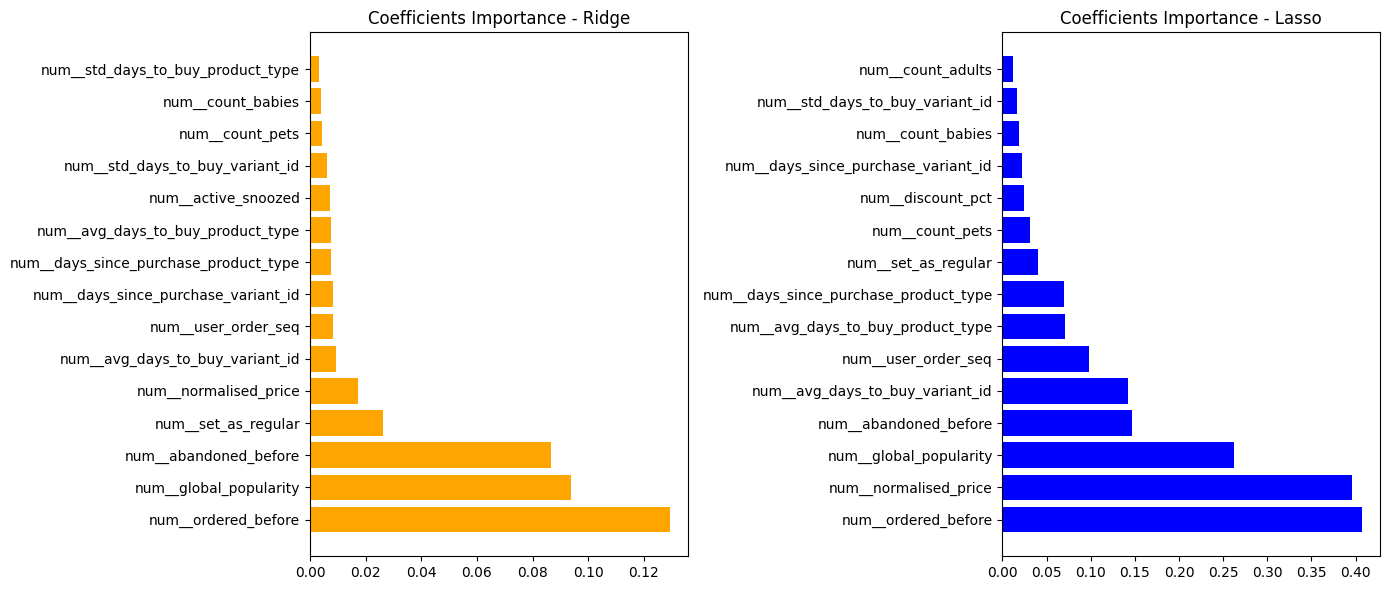

In [32]:
# Ridge

best_ridge = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(penalty='l2', solver = 'liblinear', C=0.0001))
      ]
   )

best_ridge.fit(X_train, y_train)

# Lasso

best_lasso = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(penalty='l1', solver = 'liblinear', C=0.1))
      ]
   )

best_lasso.fit(X_train, y_train)


# Extract Coefficients
feature_names = preprocessor.get_feature_names_out()

importance_ridge = pd.DataFrame({
    'feature': feature_names,
    'abs_coef': abs(best_ridge.named_steps['model'].coef_[0])
}).sort_values('abs_coef', ascending=False).head(15)

importance_lasso = pd.DataFrame({
    'feature': feature_names,
    'abs_coef': abs(best_lasso.named_steps['model'].coef_[0])
}).sort_values('abs_coef', ascending=False).head(15)

# Plot

fig, ax = plt.subplots(1,2,figsize = (14,6))

ax[0].barh(importance_ridge['feature'], importance_ridge['abs_coef'], color= 'orange')
ax[1].barh(importance_lasso['feature'], importance_lasso['abs_coef'], color= 'blue')

ax[0].set_title('Coefficients Importance - Ridge')
ax[1].set_title('Coefficients Importance - Lasso')
plt.tight_layout()


### Best Model with 3 Features 

In [34]:
top_features = ['ordered_before', 'global_popularity', 'abandoned_before']

X_train_top = X_train[top_features]
X_val_top = X_val[top_features]

preprocessor_top = StandardScaler()

model_ridge_top = Pipeline(
    steps=[
        ('preprocessor', preprocessor_top),
        ('model', LogisticRegression(penalty='l2', solver='liblinear', C=0.0001))
    ]
)
model_ridge_top.fit(X_train_top, y_train)
probs_ridge_top = model_ridge_top.predict_proba(X_val_top)[:,1]

model_lasso_top = Pipeline(
    steps=[
        ('preprocessor', StandardScaler()),
        ('model', LogisticRegression(penalty='l1', solver='liblinear', C=0.1))
    ]
)
model_lasso_top.fit(X_train_top, y_train)
probs_lasso_top = model_lasso_top.predict_proba(X_val_top)[:,1]

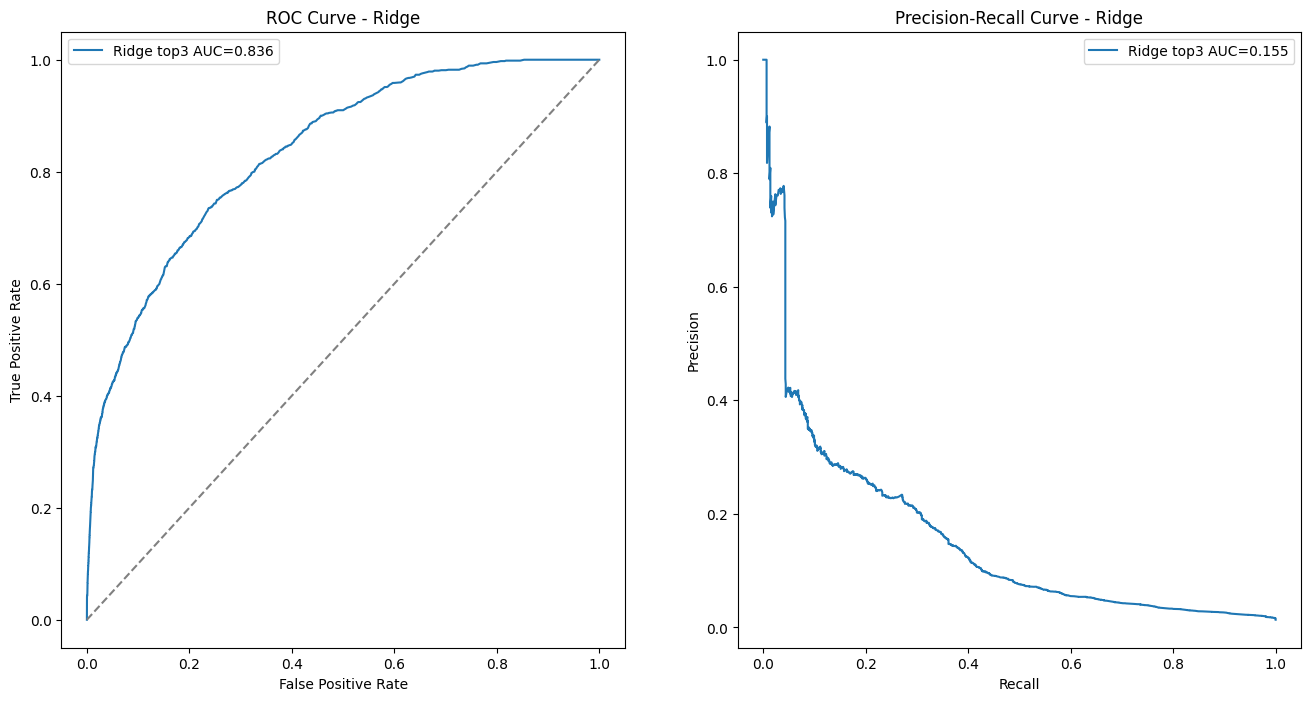

In [41]:
# ROC
fig, ax = plt.subplots(1,2,figsize = (16,8))
fpr, tpr, _ = roc_curve(y_val, probs_ridge_top)
roc_auc = auc(fpr, tpr)

ax[0].plot(fpr, tpr, label=f'Ridge top3 AUC={roc_auc:.3f}')

# Precision Recall
precision, recall, _ = precision_recall_curve(y_val, probs_ridge_top)
pr_auc = auc(recall, precision)

ax[1].plot(recall, precision, label=f'Ridge top3 AUC={pr_auc:.3f}')


# formato ROC
ax[0].plot([0,1], [0,1], linestyle='--', color='grey')
ax[0].set_title('ROC Curve - Ridge')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_xlabel('False Positive Rate')
ax[0].legend()

# formato PR
ax[1].set_title('Precision-Recall Curve - Ridge')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

Both Ridge and Lasso regression were evaluated across Cs = (1e-4, 1e-1, 1, 10, 100). 

Given the class imbalance in the dataset, PR AUC was used as the primary evaluation metric over ROC AUC.

Ridge achieved the best performance with C = 0.0001 (ROC AUC = 0.827, PR AUC = 0.170), outperforming Lasso, whose best model at C = 0.1 yielded a ROC AUC of 0.797 and PR AUC of 0.166. 

Ridge was therefore selected as the stronger linear model. The strong performance at C = 0.0001 — the highest regularisation value tested — is consistent with working on a reduced sample of 500 orders, where higher regularisation helps 
prevent overfitting and produces a more conservative, better-generalising decision boundary.

Feature importance analysis identified three key predictors: ordered_before, global_popularity, and abandoned_before. Retraining Ridge with only these features maintained a strong ROC AUC of 0.830, though PR AUC decreased slightly to 0.155 — a reasonable tradeoff given the significant reduction in model complexity.

Overall, linear models provide a solid baseline for predicting purchase intent. The dominance of ordered_before and abandoned_before as top features suggests that past user interaction with a product is the strongest signal for future purchase, which aligns well with the goal of targeting push notifications to users who have already shown interest in a product.